In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

In [10]:
s1 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')
s2 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')
df = pd.concat([s1, s2], ignore_index=True)

df = df.rename(columns={'Invoice': 'InvoiceNo', 'Price': 'UnitPrice', 'Customer ID': 'CustomerID'})

df = df.dropna(subset=['Description'])                  
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]     

df['Description'] = df['Description'].str.strip()

exclude = ['DOTCOM POSTAGE','POSTAGE','Manual','CARRIAGE','BANK CHARGES',
           'SAMPLES','AMAZON FEE','CRUK Commission','Adjust bad debt']
df = df[~df['Description'].isin(exclude)]

df['Sales'] = df['Quantity'] * df['UnitPrice']

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Kept as datetime64 instead of Python date object
df['Week'] = df['InvoiceDate'].dt.to_period('W').dt.start_time

weekly_total_sales_2yr = (
    df.groupby('Week', as_index=False)['Sales']
      .sum()
      .sort_values('Week')
      .reset_index(drop=True)
)

weekly_total_sales_2yr.to_csv('weekly_total_sales_2yr.csv', index=False)

In [11]:
top15 = (df.groupby('Description')['Sales']
           .sum()
           .sort_values(ascending=False)
           .head(15)
           .index
           .tolist())

d = df[df['Description'].isin(top15)].copy()

weekly_top15 = (d.groupby(['Week', 'Description'])
                  .agg(
                      Quantity=('Quantity', 'sum'),
                      Sales=('Sales', 'sum'),
                      AvgUnitPrice=('UnitPrice', 'mean'),
                      Orders=('InvoiceNo', 'nunique')
                  )
                  .sort_values(['Description', 'Week'])
                  .reset_index())

weekly_top15.to_csv('weekly_top15_products_2yr.csv', index=False)
df = pd.read_csv('weekly_top15_products_2yr.csv')

df.head()

,Week,Description,Quantity,Sales,AvgUnitPrice,Orders
0,2009-11-30,ASSORTED COLOUR BIRD ORNAMENT,2023,3160.37,2.233953,41
1,2009-12-07,ASSORTED COLOUR BIRD ORNAMENT,1213,2046.22,4.192414,29
2,2009-12-14,ASSORTED COLOUR BIRD ORNAMENT,1324,2230.06,4.612424,33
3,2009-12-21,ASSORTED COLOUR BIRD ORNAMENT,82,187.28,7.777500,4
4,2010-01-04,ASSORTED COLOUR BIRD ORNAMENT,168,283.92,1.690000,9


Weekly trend slope: £842/week
Projected range in 16 weeks: £237,713 to £250,348


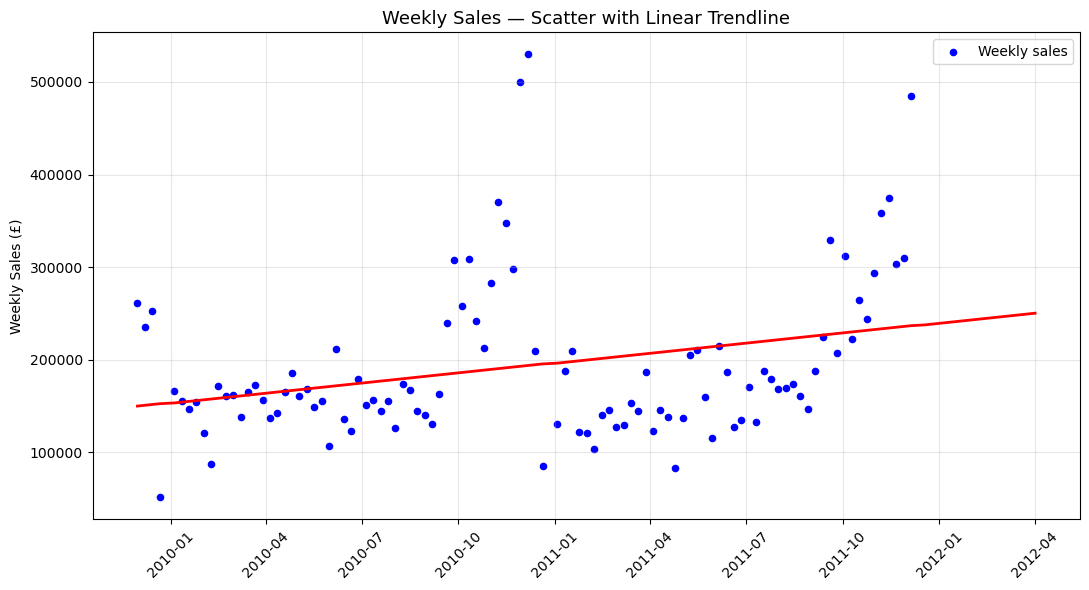

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('weekly_total_sales_2yr.csv', parse_dates=['Week'])
df = df.sort_values('Week')

df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df = df.dropna(subset=['Sales'])

df['WeekNum'] = np.arange(len(df))

slope, intercept = np.polyfit(df['WeekNum'], df['Sales'], 1)
trendline = slope * df['WeekNum'] + intercept

extra_weeks = 16  # About 4 months forecast

# Future dates starting 1 week after the final observed week
future_weeknum = np.arange(len(df), len(df) + extra_weeks)
future_dates = pd.date_range(
    start=df['Week'].iloc[-1] + pd.Timedelta(weeks=1),
    periods=extra_weeks,
    freq='W'
)

future_trend = slope * future_weeknum + intercept

combined_dates = pd.DatetimeIndex(list(df['Week']) + list(future_dates))
combined_trend = np.concatenate([trendline, future_trend])

print(f"Weekly trend slope: £{slope:,.0f}/week")
print(f"Projected range in {extra_weeks} weeks: £{future_trend[0]:,.0f} to £{future_trend[-1]:,.0f}")

# Plot
fig, ax = plt.subplots(figsize=(11, 6))

# Actual sales
ax.scatter(df['Week'], df['Sales'], s=20, label='Weekly sales', color='blue')

ax.plot(
    combined_dates,
    combined_trend,
    linewidth=2,
    color='red',
)

ax.set_title('Weekly Sales — Scatter with Linear Trendline', fontsize=13)
ax.set_ylabel('Weekly Sales (£)')
ax.legend()
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('scatter_trendline_extrapolated.png', dpi=150)
plt.show()

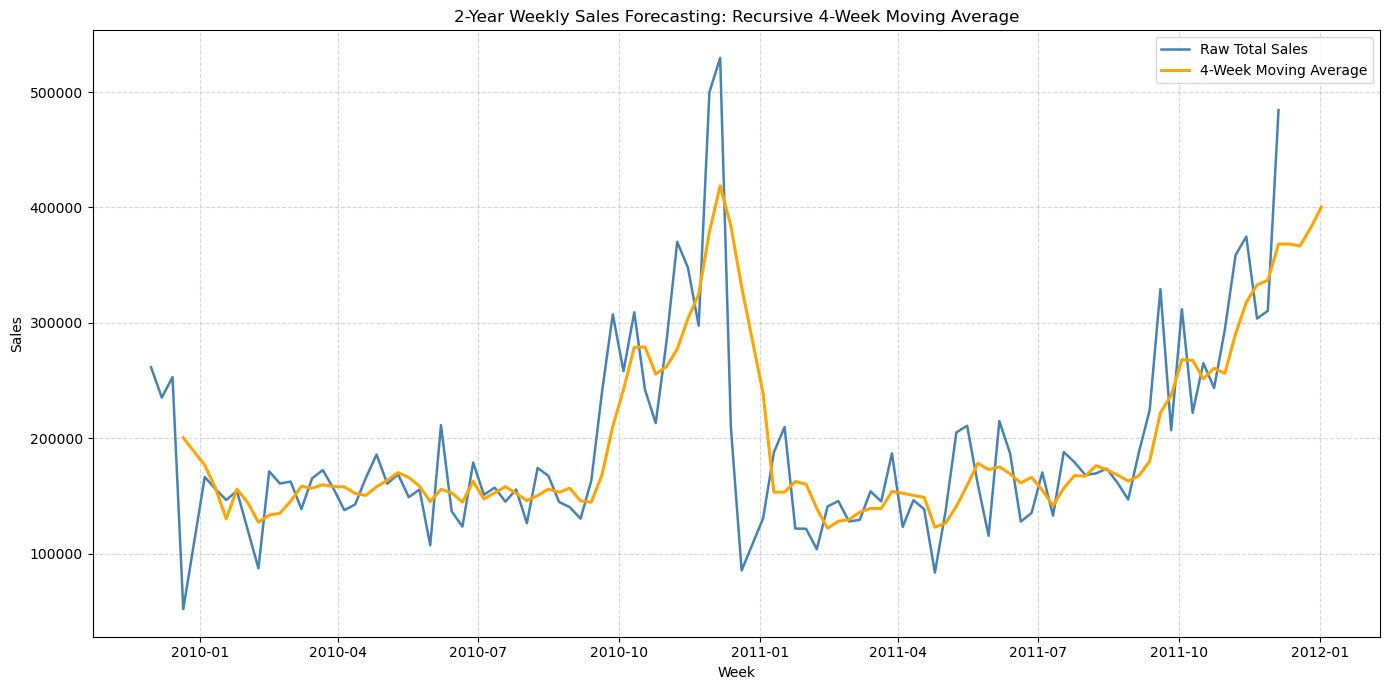

In [13]:

df = pd.read_csv("weekly_total_sales_2yr.csv")
df["Week"] = pd.to_datetime(df["Week"])
df = df.sort_values("Week")

df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
df = df.dropna(subset=["Sales"])

df["MA4"] = df["Sales"].rolling(window=4, min_periods=4).mean()

forecast_weeks = 4
forecast_steps = []

history = df["Sales"].tolist()
last_date = df["Week"].iloc[-1]

for i in range(1, forecast_weeks + 1):
    forecast_value = np.mean(history[-4:])
    forecast_date = last_date + pd.Timedelta(weeks=i)

    forecast_steps.append({
        "Week": forecast_date,
        "Forecast": forecast_value
    })

    history.append(forecast_value)

forecast_df = pd.DataFrame(forecast_steps)

# Aligned historical MA dates with non-null values only
ma4_dates = df.loc[df["MA4"].notna(), "Week"]
ma4_values = df["MA4"].dropna()


combined_dates = pd.DatetimeIndex(list(ma4_dates) + list(forecast_df["Week"]))
combined_ma = np.concatenate([ma4_values.to_numpy(), forecast_df["Forecast"].to_numpy()])

plt.figure(figsize=(14, 7))

plt.plot(
    df["Week"],
    df["Sales"],
    label="Raw Total Sales",
    color="steelblue",
    linewidth=1.8
)

plt.plot(
    combined_dates,
    combined_ma,
    label="4-Week Moving Average",
    color="orange",
    linewidth=2.2
)

plt.title("2-Year Weekly Sales Forecasting: Recursive 4-Week Moving Average")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

15:13:27 - cmdstanpy - INFO - Chain [1] start processing
15:13:27 - cmdstanpy - INFO - Chain [1] done processing


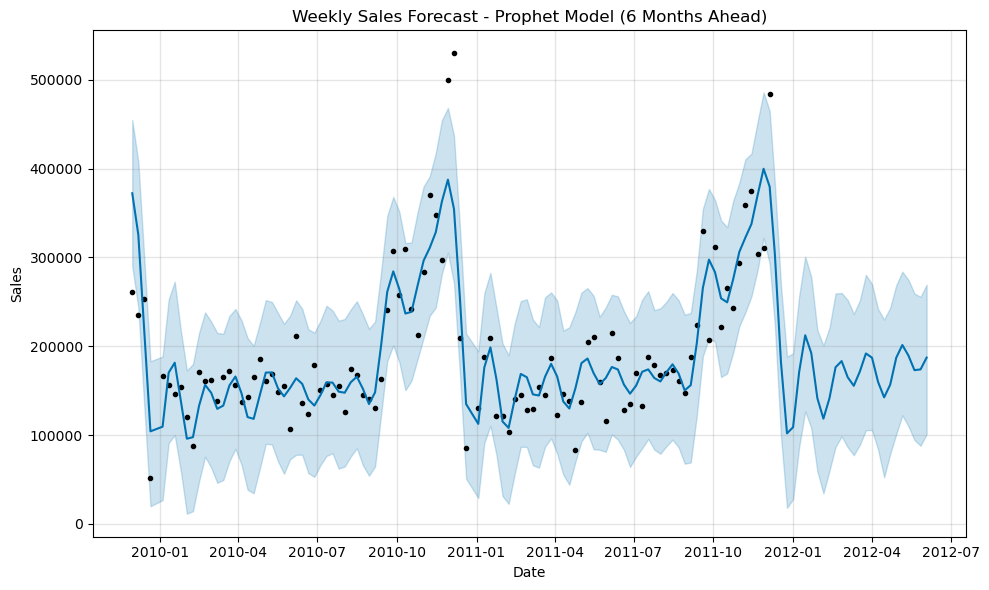

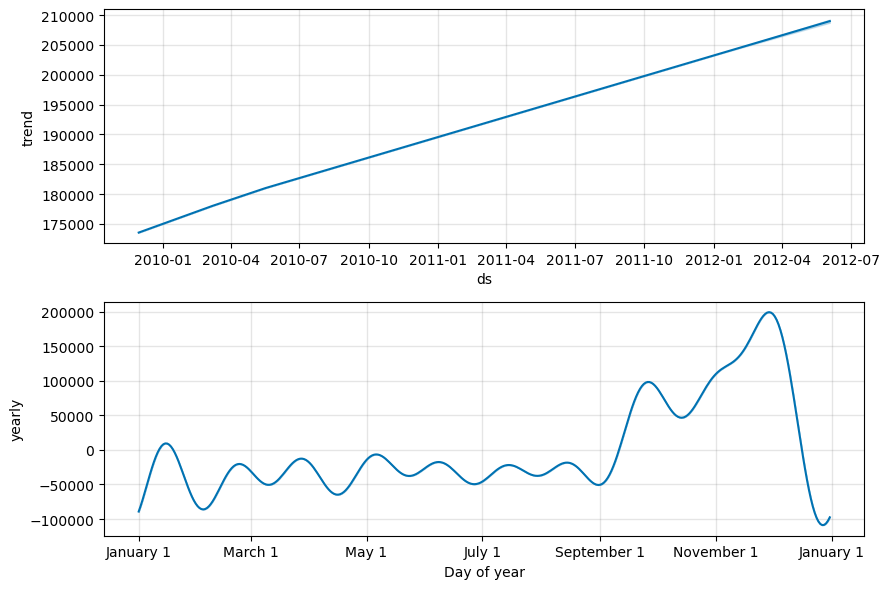

In [14]:
df = pd.read_csv("weekly_total_sales_2yr.csv")

df["Week"] = pd.to_datetime(df["Week"])

df = df.sort_values("Week")
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
df = df.dropna(subset=["Sales"])

prophet_df = pd.DataFrame({
    "ds": df["Week"],
    "y": df["Sales"]
})


model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,  # Not needed for already set weekly data
    seasonality_mode="additive",
    interval_width=0.95
)

model.fit(prophet_df)

forecast_periods = 26

future = model.make_future_dataframe(
    periods=forecast_periods,
    freq="W"
)

forecast = model.predict(future)

fig = model.plot(forecast)
plt.title("Weekly Sales Forecast - Prophet Model (6 Months Ahead)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.show()

In [15]:
df = pd.read_csv('weekly_total_sales_2yr.csv', parse_dates=['Week'])
df = df.sort_values('Week')

HORIZON = 12

train = df.iloc[:-HORIZON].copy()
test = df.iloc[-HORIZON:].copy()
actual = test['Sales'].values

# Trendline forecast
train['WeekNum'] = np.arange(len(train))
slope, intercept = np.polyfit(train['WeekNum'], train['Sales'], 1)
future_weeknum = np.arange(len(train), len(train) + HORIZON)
trend_forecast = slope * future_weeknum + intercept

# Moving average forecast
ma_value = train['Sales'].tail(4).mean()
ma_forecast = np.array([ma_value] * HORIZON)

# Prophet forecast 
prophet_train = train.rename(columns={'Week': 'ds', 'Sales': 'y'})[['ds', 'y']]

import holidays as pyholidays
uk_holidays = pyholidays.country_holidays('UK', years=range(2009, 2012))
holiday_df = pd.DataFrame({
    'holiday': list(uk_holidays.values()),
    'ds': pd.to_datetime(list(uk_holidays.keys())),
    'lower_window': -3,
    'upper_window': 3,
})

model = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                 seasonality_mode='additive', interval_width=0.95,
                 holidays=holiday_df)
model.fit(prophet_train)
future = model.make_future_dataframe(periods=HORIZON, freq='W')
forecast = model.predict(future)
prophet_forecast = forecast.tail(HORIZON)['yhat'].values

# Comparison
def mae_mape(actual, pred):
    mae = np.mean(np.abs(actual - pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return mae, mape

results = pd.DataFrame({
    'Week': test['Week'].values,
    'Actual': actual,
    'Trendline': trend_forecast.round(0),
    'MovingAvg': ma_forecast.round(0),
    'Prophet': prophet_forecast.round(0)
})
print(results)

for name, pred in [('Trendline', trend_forecast), ('MovingAvg', ma_forecast), ('Prophet', prophet_forecast)]:
    mae, mape = mae_mape(actual, pred)
    print(f"{name:10s} MAE: {mae:>10,.0f}   MAPE: {mape:>5.1f}%")

results.to_csv('three_way_comparison.csv', index=False)

15:13:28 - cmdstanpy - INFO - Chain [1] start processing
15:13:29 - cmdstanpy - INFO - Chain [1] done processing


         Week      Actual  Trendline  MovingAvg   Prophet
0  2011-09-19  329191.141   182203.0   180130.0  257985.0
1  2011-09-26  206879.251   182284.0   180130.0  306778.0
2  2011-10-03  311850.760   182364.0   180130.0  307546.0
3  2011-10-10  222007.210   182445.0   180130.0  279573.0
4  2011-10-17  265059.280   182525.0   180130.0  263558.0
5  2011-10-24  243566.290   182606.0   180130.0  275809.0
6  2011-10-31  294049.210   182686.0   180130.0  299408.0
7  2011-11-07  358755.370   182767.0   180130.0  317809.0
8  2011-11-14  374736.150   182847.0   180130.0  340078.0
9  2011-11-21  303690.320   182928.0   180130.0  379931.0
10 2011-11-28  310368.860   183008.0   180130.0  417003.0
11 2011-12-05  484290.640   183089.0   180130.0  400114.0
Trendline  MAE:    126,058   MAPE:  37.8%
MovingAvg  MAE:    128,574   MAPE:  38.6%
Prophet    MAE:     51,228   MAPE:  17.5%


Hid the last 12 weeks of real sales, had all three methods predict them blind using only earlier data, then compared each prediction to what actually happened.

In [16]:
df = pd.read_csv('weekly_top15_products_2yr.csv', parse_dates=['Week'])

ranking = df.groupby('Description')['Sales'].sum().sort_values(ascending=False)
print(ranking.head())

best_product_name = ranking.index[0]

p = df[df['Description'] == best_product_name].sort_values('Week')



Description
REGENCY CAKESTAND 3 TIER              344563.25
WHITE HANGING HEART T-LIGHT HOLDER    266923.55
PAPER CRAFT , LITTLE BIRDIE           168469.60
JUMBO BAG RED RETROSPOT               150935.56
PARTY BUNTING                         149187.05
Name: Sales, dtype: float64


Could be used to build propeht models on individual products, this will show when they sell best which can inform business decisions when anticipating large/low sales